In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, RepeatedStratifiedKFold, LeaveOneOut
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline

Importando os data-sets

In [61]:
train_df = pd.read_csv('train.csv', index_col=[0])
test_df = pd.read_csv('test.csv', index_col=[0])

In [62]:
train_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
2,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
3,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
4,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia


## Análise visual dos dados

In [ ]:
colors = {'Hernia': '#2196F3', 'Normal': '#4CAF50', 'Spondylolisthesis': '#F44336'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot do feature mais importante por classe
for ax_col, col in zip(axes[0], ['degree_spondylolisthesis', 'sacral_slope']):
    data_by_class = [train_df[train_df['class'] == cls][col] for cls in colors]
    bp = ax_col.boxplot(data_by_class, patch_artist=True, labels=list(colors.keys()))
    for patch, color in zip(bp['boxes'], colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_col.set_title(f'{col} por classe')
    ax_col.set_xlabel('Classe')
    ax_col.set_ylabel(col)
    ax_col.tick_params(axis='x', rotation=15)

# 2. Scatter: degree_spondylolisthesis vs sacral_slope
for cls, grp in train_df.groupby('class'):
    axes[1, 0].scatter(grp['degree_spondylolisthesis'], grp['sacral_slope'],
                       label=cls, alpha=0.6, color=colors[cls])
axes[1, 0].set_xlabel('degree_spondylolisthesis')
axes[1, 0].set_ylabel('sacral_slope')
axes[1, 0].legend()
axes[1, 0].set_title('Scatter: degree_spondylolisthesis vs sacral_slope')

# 3. Distribuição das classes
class_counts = train_df['class'].value_counts()
bars = axes[1, 1].bar(class_counts.index, class_counts.values,
                      color=[colors[c] for c in class_counts.index], alpha=0.7)
for bar, count in zip(bars, class_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    str(count), ha='center', fontweight='bold')
axes[1, 1].set_title('Distribuição das classes')
axes[1, 1].set_xlabel('Classe')
axes[1, 1].set_ylabel('Quantidade')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Exploração dos dados - Coluna Vertebral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Padrões observados

Os gráficos revelam um padrão muito claro:

- **`degree_spondylolisthesis`** é o principal discriminador entre as classes.  
  A classe **Spondylolisthesis** concentra valores muito mais altos (mediana ~> 40), enquanto Hernia e Normal ficam próximas de zero.  
  Isso cria uma **separação quase linear** — um simples limiar nessa feature já classifica Spondylolisthesis com alta precisão.

- **`sacral_slope`** também contribui: Spondylolisthesis tende a ter valores mais altos, reforçando a separabilidade.

- **Hernia e Normal** se sobrepõem mais, especialmente no scatter — são as classes mais difíceis de distinguir entre si.

#### Conclusão: qual classe é mais fácil de classificar?

> **Spondylolisthesis** é de longe a classe mais fácil.  
> O alto valor de `degree_spondylolisthesis` a separa claramente das demais.  
> Hernia e Normal são mais desafiadoras, pois compartilham um espaço de features muito similar.

Dividindo o dataset de treino: 80% treino e 20% teste, e definindo a estratégia **Leave One Out** para validação cruzada

In [ ]:
X = train_df.drop(columns=['class'])
y = train_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Leave One Out: cada amostra é usada uma vez como conjunto de teste (n folds = n amostras)
cv_strategy = LeaveOneOut()

Definindo parâmetros para o Grid Search (busca de hiperparâmetros com Leave One Out)

In [64]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 3, 4, 5, 6],
    'min_samples_leaf': [2, 3, 4, 5, 8],
    'ccp_alpha': [0.0, 0.0055, 0.0058, 0.0087],
    'class_weight': [None, 'balanced']
}

In [65]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00550509 0.00578035 0.00867052 0.00924855 0.00945875
 0.01109827 0.01114781 0.01256671 0.01801667 0.02987995 0.03243085
 0.06439853 0.34642826]


Grid Search

In [67]:
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=cv_strategy,
    scoring='accuracy'
)

grid_search.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'ccp_alpha': [0.0, 0.0055, 0.0058, 0.0087],
                         'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, None],
                         'min_samples_leaf': [2, 3, 4, 5, 8],
                         'min_samples_split': [2, 3, 4, 5, 6]},
             scoring='accuracy')

In [68]:
print('Melhores parâmetros:')
print(grid_search.best_params_)

print('Melhor accuracy na validação cruzada:')
print(grid_search.best_score_)

Melhores parâmetros:
{'ccp_alpha': 0.0055, 'class_weight': None, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}
Melhor accuracy na validação cruzada:
0.8619047619047621


In [69]:
model = grid_search.best_estimator_

model.fit(X_train, y_train)
predictions = model.predict(X_test)

final_predictions = model.predict(test_df)

In [70]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

degree_spondylolisthesis    0.679144
sacral_slope                0.235423
pelvic_radius               0.063578
pelvic_tilt                 0.021854
pelvic_incidence            0.000000
lumbar_lordosis_angle       0.000000
dtype: float64


Resultados

In [71]:
print('Accuracy:', accuracy_score(y_test, predictions))
print('F1:', f1_score(y_test, predictions, average='macro'))
print('Precision:', precision_score(y_test, predictions, average='macro'))
print('Recall:', recall_score(y_test, predictions, average='macro'))

Accuracy: 0.8636363636363636
F1: 0.8327220490250015
Precision: 0.8285714285714286
Recall: 0.8386243386243386


In [72]:
scores = cross_val_score(grid_search.best_estimator_, X, y, cv=cv_strategy, scoring='accuracy')
print(scores.mean(), scores.std())

0.8619047619047621 0.061051240667117056


Matriz de confusão

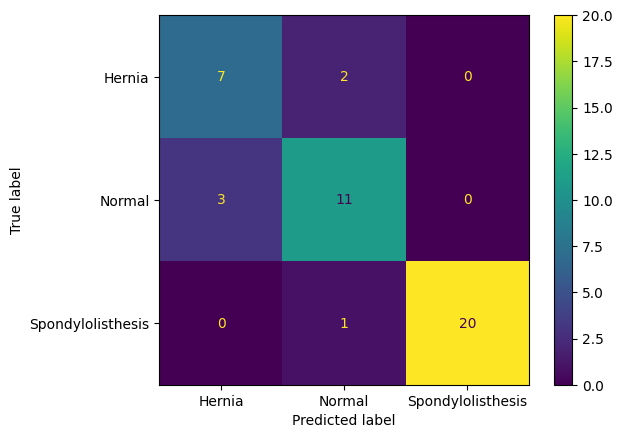

In [73]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions)

Criando arquivo de submissão

In [74]:
def create_submission_file(predictions, test_df, submission_file_name="submission.csv"):
    submission_df = pd.DataFrame({'id': test_df.index, 'Target': predictions})
    submission_df.to_csv(submission_file_name, index=False)
    print(f"Submission file '{submission_file_name}' created successfully.")

In [75]:
create_submission_file(final_predictions, test_df)

Submission file 'submission.csv' created successfully.
